In [8]:
#pip install scikit-learn
#pip install tensorflow

In [9]:
import tensorflow as tf
import sklearn
print("Sklearn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)

Sklearn version: 1.8.0
TensorFlow version: 2.21.0


In [10]:
# Dia-1_modelagem.ipynb

import pandas as pd

print("Iniciando o processamento definitivo do Dia 1...")

# ==========================================
# 1. CARREGANDO AS BASES (.XLSX)
# ==========================================
caminho_dontgo = '/workspaces/analise-de-dados-vale/datasets/datasets_full/telemetria/desenvolver_dontgo.xlsx'
caminho_apont = '/workspaces/analise-de-dados-vale/datasets/datasets_full/apontamentos/desenvolver_apontamentos.xlsx'

df_alertas = pd.read_excel(caminho_dontgo)
df_apont = pd.read_excel(caminho_apont)

# ==========================================
# 2. LIMPANDO OS APONTAMENTOS (CICLOS)
# ==========================================
print("\nLimpando inconsistências de tempo...")
# Assumindo que as colunas de tempo no arquivo de apontamentos se chamam 'Inicio' e 'Fim'
if 'Inicio' in df_apont.columns and 'Fim' in df_apont.columns:
    df_apont['Inicio'] = pd.to_datetime(df_apont['Inicio'], errors='coerce')
    df_apont['Fim'] = pd.to_datetime(df_apont['Fim'], errors='coerce')
    
    # Remove datas nulas e viagens no tempo (Fim antes do Início)
    tamanho_antes = len(df_apont)
    df_apont = df_apont.dropna(subset=['Inicio', 'Fim'])
    df_apont = df_apont[df_apont['Fim'] > df_apont['Inicio']].copy()
    print(f"-> Registros de apontamentos limpos: {len(df_apont)} (Removidos: {tamanho_antes - len(df_apont)})")
else:
    print("-> ATENÇÃO: As colunas 'Inicio' e 'Fim' não foram encontradas em apontamentos. Verifique os nomes.")
    print("Colunas disponíveis:", df_apont.columns.tolist())

# ==========================================
# 3. AVALIAÇÃO DA VARIÁVEL ALVO (TARGET)
# ==========================================
print("\n--- RESUMO DO DIA 1: O NOSSO TARGET ---")
print("Distribuição da coluna 'Is_Dont_Go' (0 = Normal, 1 = Falha Crítica):")

# Verifica os valores únicos (pode ser 0/1, True/False, ou 'Sim'/'Não')
distribuicao = df_alertas['Is_Dont_Go'].value_counts(dropna=False, normalize=True) * 100
print(distribuicao)

# Isolando apenas os alertas críticos para usarmos no motor temporal do Dia 2
# Ajuste o valor "1" se a coluna usar outro padrão, como "True" ou "Sim"
alertas_criticos = df_alertas[df_alertas['Is_Dont_Go'] == 1].copy()
print(f"\nTotal de alertas estritamente 'Don't Go' mapeados na frota: {len(alertas_criticos)}")

Iniciando o processamento definitivo do Dia 1...

Limpando inconsistências de tempo...
-> Registros de apontamentos limpos: 100 (Removidos: 0)

--- RESUMO DO DIA 1: O NOSSO TARGET ---
Distribuição da coluna 'Is_Dont_Go' (0 = Normal, 1 = Falha Crítica):
Is_Dont_Go
0    99.319728
1     0.680272
Name: proportion, dtype: float64

Total de alertas estritamente 'Don't Go' mapeados na frota: 1


In [11]:
# Dia2_features.ipynb

import pandas as pd
import glob
import os
import gc

print("🚀 Iniciando Dia 2: Geração da Base Analítica (ABT) em Lotes...")

# ==========================================
# 1. MAPEAMENTO DOS ARQUIVOS
# ==========================================
pasta_dontgo = '/workspaces/analise-de-dados-vale/datasets/datasets_full/telemetria/'
pasta_apont = '/workspaces/analise-de-dados-vale/datasets/datasets_full/apontamentos/'

arquivos_dontgo = glob.glob(os.path.join(pasta_dontgo, '*.parquet'))
arquivos_apontamentos = glob.glob(os.path.join(pasta_apont, '*.parquet'))

# ==========================================
# 2. CARREGAR APENAS AS FALHAS CRÍTICAS NA RAM
# ==========================================
print(f"-> Mapeando regras estritas ('Don't Go') em {len(arquivos_dontgo)} arquivos...")
df_alertas_list = []

for f in arquivos_dontgo:
    temp_df = pd.read_parquet(f, columns=['TAG', 'Data_Evento', 'Is_Dont_Go'], engine='fastparquet')
    df_alertas_list.append(temp_df[temp_df['Is_Dont_Go'] == 1])

falhas_criticas = pd.concat(df_alertas_list, ignore_index=True)
falhas_criticas['Data_Evento'] = pd.to_datetime(falhas_criticas['Data_Evento']).dt.tz_localize(None).astype('datetime64[ns]')
falhas_criticas['TAG'] = falhas_criticas['TAG'].astype(str).str.upper().str.strip()
falhas_criticas.sort_values('Data_Evento', inplace=True)

del df_alertas_list
gc.collect()

# ==========================================
# 3. PROCESSAMENTO EM LOTES E CRIAÇÃO DO DF_ABT
# ==========================================
print("\n-> Varrendo histórico para criar features...")

lotes_analiticos = []
janela_preditiva = pd.Timedelta(hours=4)

for i, arquivo in enumerate(arquivos_apontamentos, 1):
    print(f"   Processando lote de apontamentos {i}/{len(arquivos_apontamentos)}...")
    
    amostra_cols = pd.read_parquet(arquivo, engine='fastparquet').columns
    col_tag_apont = next((col for col in amostra_cols if col.upper() in ['TAG', 'EQUIPAMENTO']), 'TAG')
    
    df_lote = pd.read_parquet(arquivo, columns=[col_tag_apont, 'Inicio', 'Fim'], engine='fastparquet')
    
    df_lote['Inicio'] = pd.to_datetime(df_lote['Inicio'], errors='coerce')
    df_lote['Fim'] = pd.to_datetime(df_lote['Fim'], errors='coerce')
    df_lote = df_lote.dropna(subset=['Inicio', 'Fim'])
    df_lote = df_lote[df_lote['Fim'] > df_lote['Inicio']].copy()
    
    df_lote[col_tag_apont] = df_lote[col_tag_apont].astype(str).str.upper().str.strip()
    df_lote['Fim'] = df_lote['Fim'].dt.tz_localize(None).astype('datetime64[ns]')
    
    df_lote.sort_values('Fim', inplace=True)
    
    # Cruzamento temporal
    cruzamento = pd.merge_asof(
        df_lote,
        falhas_criticas.rename(columns={'Data_Evento': 'Proxima_Falha_Futura'}),
        left_on='Fim',
        right_on='Proxima_Falha_Futura',
        left_by=col_tag_apont,
        right_by='TAG',
        direction='forward'
    )
    
    # Gerando as colunas (Features e Target)
    df_lote['Target_4H'] = ((cruzamento['Proxima_Falha_Futura'] - cruzamento['Fim']) <= janela_preditiva).astype(int)
    df_lote['Duracao_Ciclo_Minutos'] = (df_lote['Fim'] - df_lote['Inicio']).dt.total_seconds() / 60
    df_lote['Hora_Inicio'] = df_lote['Inicio'].dt.hour
    df_lote['Dia_Semana'] = df_lote['Inicio'].dt.dayofweek
    
    # Salva apenas a matriz matemática leve para o TensorFlow
    df_leve = df_lote[['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 'Target_4H']].copy()
    lotes_analiticos.append(df_leve)
    
    del df_lote, cruzamento
    gc.collect()

# ==========================================
# 4. CONSOLIDAÇÃO FINAL DA BASE (ABT)
# ==========================================
# Essa é a variável que o Dia 3 precisa para rodar!
df_abt = pd.concat(lotes_analiticos, ignore_index=True)
del lotes_analiticos
gc.collect()

print("\n" + "="*50)
print(f"✅ Base Analítica (df_abt) gerada com sucesso: {len(df_abt)} linhas.")
print("="*50)
print(df_abt.head())

🚀 Iniciando Dia 2: Geração da Base Analítica (ABT) em Lotes...
-> Mapeando regras estritas ('Don't Go') em 6 arquivos...



-> Varrendo histórico para criar features...
   Processando lote de apontamentos 1/1...

✅ Base Analítica (df_abt) gerada com sucesso: 377907 linhas.
   Duracao_Ciclo_Minutos  Hora_Inicio  Dia_Semana  Target_4H
0               3.716667            0           2          0
1               5.333333            0           2          1
2               2.866667            0           2          0
3               0.116667            0           2          0
4               9.483333            0           2          1


In [12]:
# DIA2_UPT.ipynb usando arquivos .PARQUET e criando a feature de "febre da máquina" (Rolling Window de sintomas nas últimas 24h)

import pandas as pd
import glob
import os
import gc

print("🚀 Iniciando Sprint 4: Engenharia de Sintomas (Rolling Window)...")

# ==========================================
# 1. MAPEAMENTO DOS ARQUIVOS
# ==========================================
pasta_dontgo = '/workspaces/analise-de-dados-vale/datasets/datasets_full/telemetria/'
pasta_apont = '/workspaces/analise-de-dados-vale/datasets/datasets_full/apontamentos/'

arquivos_dontgo = glob.glob(os.path.join(pasta_dontgo, '*.parquet'))
arquivos_apontamentos = glob.glob(os.path.join(pasta_apont, '*.parquet'))

# ==========================================
# 2. CARREGANDO TODO O HISTÓRICO DE ALARMES
# ==========================================
print(f"-> Mapeando Falhas Críticas e Sintomas (Alarmes Menores)...")
df_alertas_list = []

for f in arquivos_dontgo:
    # Agora trazemos TODOS os alarmes, não apenas os críticos
    temp_df = pd.read_parquet(f, columns=['TAG', 'Data_Evento', 'Is_Dont_Go'], engine='fastparquet')
    df_alertas_list.append(temp_df)

todos_alarmes = pd.concat(df_alertas_list, ignore_index=True)
todos_alarmes['Data_Evento'] = pd.to_datetime(todos_alarmes['Data_Evento']).dt.tz_localize(None).astype('datetime64[ns]')
todos_alarmes['TAG'] = todos_alarmes['TAG'].astype(str).str.upper().str.strip()
del df_alertas_list
gc.collect()

# Separando: O que é "Morte" (Target) e o que é "Sintoma" (Feature)
falhas_criticas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 1].copy()
falhas_criticas.sort_values('Data_Evento', inplace=True)

sintomas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 0].copy()
del todos_alarmes
gc.collect()

# ==========================================
# 3. CRIANDO A "MEMÓRIA DE 24H" DOS SINTOMAS
# ==========================================
print("-> Calculando febre da máquina (Acúmulo de sintomas nas últimas 24h)...")
# Usamos o groupby e rolling para contar quantos avisos a máquina deu em 24h
sintomas.sort_values('Data_Evento', inplace=True)
sintomas.set_index('Data_Evento', inplace=True)

# Conta os sintomas e reseta o index para podermos fazer o merge depois
sintomas_24h = sintomas.groupby('TAG')['Is_Dont_Go'].rolling('24h').count().reset_index(name='Sintomas_Ultimas_24H')
sintomas_24h.sort_values('Data_Evento', inplace=True)

del sintomas
gc.collect()
print(f"   [OK] Dicionário de sintomas calculado: {len(sintomas_24h)} marcos de tempo.")

# ==========================================
# 4. PROCESSAMENTO EM LOTES E CRIAÇÃO DO DF_ABT ENRIQUECIDO
# ==========================================
print("\n-> Varrendo histórico para cruzar Passado (Sintoma) e Futuro (Quebra)...")

lotes_analiticos = []
janela_preditiva = pd.Timedelta(hours=4)

for i, arquivo in enumerate(arquivos_apontamentos, 1):
    print(f"   Processando lote de apontamentos {i}/{len(arquivos_apontamentos)}...")
    
    amostra_cols = pd.read_parquet(arquivo, engine='fastparquet').columns
    col_tag_apont = next((col for col in amostra_cols if col.upper() in ['TAG', 'EQUIPAMENTO']), 'TAG')
    
    df_lote = pd.read_parquet(arquivo, columns=[col_tag_apont, 'Inicio', 'Fim'], engine='fastparquet')
    
    df_lote['Inicio'] = pd.to_datetime(df_lote['Inicio'], errors='coerce')
    df_lote['Fim'] = pd.to_datetime(df_lote['Fim'], errors='coerce')
    df_lote = df_lote.dropna(subset=['Inicio', 'Fim'])
    df_lote = df_lote[df_lote['Fim'] > df_lote['Inicio']].copy()
    
    df_lote[col_tag_apont] = df_lote[col_tag_apont].astype(str).str.upper().str.strip()
    df_lote['Inicio'] = df_lote['Inicio'].dt.tz_localize(None).astype('datetime64[ns]')
    df_lote['Fim'] = df_lote['Fim'].dt.tz_localize(None).astype('datetime64[ns]')
    
    # --- MERGE 1: OLHANDO PARA O PASSADO (SINTOMAS) ---
    df_lote.sort_values('Inicio', inplace=True)
    cruzamento_passado = pd.merge_asof(
        df_lote,
        sintomas_24h,
        left_on='Inicio',
        right_on='Data_Evento',
        left_by=col_tag_apont,
        right_by='TAG',
        direction='backward' # Traz a contagem do momento exato ANTES do ciclo começar
    )
    
    # --- MERGE 2: OLHANDO PARA O FUTURO (TARGET) ---
    cruzamento_passado.sort_values('Fim', inplace=True)
    cruzamento_futuro = pd.merge_asof(
        cruzamento_passado,
        falhas_criticas.rename(columns={'Data_Evento': 'Proxima_Falha_Futura'}),
        left_on='Fim',
        right_on='Proxima_Falha_Futura',
        left_by=col_tag_apont,
        right_by='TAG',
        direction='forward' # Traz a próxima quebra
    )
    
    # Gerando as colunas Finais
    df_final = cruzamento_futuro.copy()
    df_final['Target_4H'] = ((df_final['Proxima_Falha_Futura'] - df_final['Fim']) <= janela_preditiva).astype(int)
    df_final['Duracao_Ciclo_Minutos'] = (df_final['Fim'] - df_final['Inicio']).dt.total_seconds() / 60
    df_final['Hora_Inicio'] = df_final['Inicio'].dt.hour
    df_final['Dia_Semana'] = df_final['Inicio'].dt.dayofweek
    
    # Se for NaN, significa que teve 0 sintomas nas últimas 24h
    df_final['Sintomas_Ultimas_24H'] = df_final['Sintomas_Ultimas_24H'].fillna(0)
    
    # Salva a matriz leve enriquecida!
    df_leve = df_final[['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 'Sintomas_Ultimas_24H', 'Target_4H']].copy()
    lotes_analiticos.append(df_leve)
    
    del df_lote, cruzamento_passado, cruzamento_futuro, df_final
    gc.collect()

df_abt = pd.concat(lotes_analiticos, ignore_index=True)
del lotes_analiticos
gc.collect()

print("\n" + "="*50)
print(f"✅ Base Analítica ENRIQUECIDA gerada: {len(df_abt)} linhas.")
print("="*50)
print(df_abt.head())

🚀 Iniciando Sprint 4: Engenharia de Sintomas (Rolling Window)...
-> Mapeando Falhas Críticas e Sintomas (Alarmes Menores)...


-> Calculando febre da máquina (Acúmulo de sintomas nas últimas 24h)...
   [OK] Dicionário de sintomas calculado: 37144092 marcos de tempo.

-> Varrendo histórico para cruzar Passado (Sintoma) e Futuro (Quebra)...
   Processando lote de apontamentos 1/1...

✅ Base Analítica ENRIQUECIDA gerada: 377907 linhas.
   Duracao_Ciclo_Minutos  Hora_Inicio  Dia_Semana  Sintomas_Ultimas_24H  \
0               3.716667            0           2                   0.0   
1               5.333333            0           2                   0.0   
2               2.866667            0           2                   1.0   
3               0.116667            0           2                   1.0   
4               9.483333            0           2                   0.0   

   Target_4H  
0          1  
1          0  
2          1  
3          1  
4          0  


In [13]:
# DIA2_UPT.ipynb usando arquivos .PARQUET e criando as features de "Aceleração de Degradação"

import pandas as pd
import numpy as np
import glob
import os
import gc

print("🚀 Iniciando Sprint 4: Engenharia de Sintomas (Rolling Windows Múltiplas)...")

# ==========================================
# 1. MAPEAMENTO DOS ARQUIVOS
# ==========================================
pasta_dontgo = '/workspaces/analise-de-dados-vale/datasets/datasets_full/telemetria/'
pasta_apont = '/workspaces/analise-de-dados-vale/datasets/datasets_full/apontamentos/'

arquivos_dontgo = glob.glob(os.path.join(pasta_dontgo, '*.parquet'))
arquivos_apontamentos = glob.glob(os.path.join(pasta_apont, '*.parquet'))

# ==========================================
# 2. CARREGANDO TODO O HISTÓRICO DE ALARMES
# ==========================================
print(f"-> Mapeando Falhas Críticas e Sintomas (Alarmes Menores)...")
df_alertas_list = []

for f in arquivos_dontgo:
    # Trazemos TODOS os alarmes
    temp_df = pd.read_parquet(f, columns=['TAG', 'Data_Evento', 'Is_Dont_Go'], engine='fastparquet')
    df_alertas_list.append(temp_df)

todos_alarmes = pd.concat(df_alertas_list, ignore_index=True)
todos_alarmes['Data_Evento'] = pd.to_datetime(todos_alarmes['Data_Evento']).dt.tz_localize(None).astype('datetime64[ns]')
todos_alarmes['TAG'] = todos_alarmes['TAG'].astype(str).str.upper().str.strip()
del df_alertas_list
gc.collect()

# Separando: O que é "Morte" (Target) e o que é "Sintoma" (Feature)
falhas_criticas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 1].copy()
falhas_criticas.sort_values('Data_Evento', inplace=True)

sintomas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 0].copy()
del todos_alarmes
gc.collect()

# ==========================================
# 3. CRIANDO A "MEMÓRIA DE 24H, 4H E 2H"
# ==========================================
print("-> Calculando febre da máquina (Acúmulo de sintomas em 24h, 4h e 2h)...")
sintomas.sort_values('Data_Evento', inplace=True)
sintomas.set_index('Data_Evento', inplace=True)

# Calcula as 3 janelas simultaneamente para o mesmo TAG
sintomas_agg = sintomas.groupby('TAG', sort=False)['Is_Dont_Go'].rolling('24h').count().reset_index(name='Sintomas_Ultimas_24H')
sintomas_agg['Sintomas_Ultimas_4H'] = sintomas.groupby('TAG', sort=False)['Is_Dont_Go'].rolling('4h').count().values
sintomas_agg['Sintomas_Ultimas_2H'] = sintomas.groupby('TAG', sort=False)['Is_Dont_Go'].rolling('2h').count().values

sintomas_agg['Sintomas_Ultimas_24H'] = sintomas_agg['Sintomas_Ultimas_24H'].astype('float32')
sintomas_agg['Sintomas_Ultimas_4H'] = sintomas_agg['Sintomas_Ultimas_4H'].astype('float32')
sintomas_agg['Sintomas_Ultimas_2H'] = sintomas_agg['Sintomas_Ultimas_2H'].astype('float32')

sintomas_agg.sort_values('Data_Evento', inplace=True)

del sintomas
gc.collect()
print(f"   [OK] Dicionário de sintomas calculado: {len(sintomas_agg)} marcos de tempo.")

# ==========================================
# 4. PROCESSAMENTO EM LOTES E CRIAÇÃO DO DF_ABT ENRIQUECIDO
# ==========================================
print("\n-> Varrendo histórico para cruzar Passado (Sintomas) e Futuro (Quebra)...")

lotes_analiticos = []
janela_preditiva = pd.Timedelta(hours=4)

for i, arquivo in enumerate(arquivos_apontamentos, 1):
    print(f"   Processando lote de apontamentos {i}/{len(arquivos_apontamentos)}...")
    
    amostra_cols = pd.read_parquet(arquivo, engine='fastparquet').columns
    col_tag_apont = next((col for col in amostra_cols if col.upper() in ['TAG', 'EQUIPAMENTO']), 'TAG')
    
    df_lote = pd.read_parquet(arquivo, columns=[col_tag_apont, 'Inicio', 'Fim'], engine='fastparquet')
    
    df_lote['Inicio'] = pd.to_datetime(df_lote['Inicio'], errors='coerce')
    df_lote['Fim'] = pd.to_datetime(df_lote['Fim'], errors='coerce')
    df_lote = df_lote.dropna(subset=['Inicio', 'Fim'])
    df_lote = df_lote[df_lote['Fim'] > df_lote['Inicio']].copy()
    
    df_lote[col_tag_apont] = df_lote[col_tag_apont].astype(str).str.upper().str.strip()
    df_lote['Inicio'] = df_lote['Inicio'].dt.tz_localize(None).astype('datetime64[ns]')
    df_lote['Fim'] = df_lote['Fim'].dt.tz_localize(None).astype('datetime64[ns]')
    
    # --- MERGE 1: OLHANDO PARA O PASSADO (SINTOMAS MÚLTIPLOS) ---
    df_lote.sort_values('Inicio', inplace=True)
    cruzamento_passado = pd.merge_asof(
        df_lote,
        sintomas_agg,
        left_on='Inicio',
        right_on='Data_Evento',
        left_by=col_tag_apont,
        right_by='TAG',
        direction='backward'
    )
    
    # --- MERGE 2: OLHANDO PARA O FUTURO (TARGET) ---
    cruzamento_passado.sort_values('Fim', inplace=True)
    cruzamento_futuro = pd.merge_asof(
        cruzamento_passado,
        falhas_criticas.rename(columns={'Data_Evento': 'Proxima_Falha_Futura'}),
        left_on='Fim',
        right_on='Proxima_Falha_Futura',
        left_by=col_tag_apont,
        right_by='TAG',
        direction='forward'
    )
    
    # Gerando as colunas Finais
    df_final = cruzamento_futuro.copy()
    df_final['Target_4H'] = ((df_final['Proxima_Falha_Futura'] - df_final['Fim']) <= janela_preditiva).astype('int8')
    df_final['Duracao_Ciclo_Minutos'] = ((df_final['Fim'] - df_final['Inicio']).dt.total_seconds() / 60).astype('float32')
    df_final['Hora_Inicio'] = df_final['Inicio'].dt.hour.astype('int8')
    df_final['Dia_Semana'] = df_final['Inicio'].dt.dayofweek.astype('int8')
    
    # Tratando nulos das janelas
    df_final['Sintomas_Ultimas_24H'] = df_final['Sintomas_Ultimas_24H'].fillna(0)
    df_final['Sintomas_Ultimas_4H'] = df_final['Sintomas_Ultimas_4H'].fillna(0)
    df_final['Sintomas_Ultimas_2H'] = df_final['Sintomas_Ultimas_2H'].fillna(0)
    
    # Calculando a Aceleração (Evitando divisão por zero com np.where)
    df_final['Razao_Agravamento_4H'] = np.where(df_final['Sintomas_Ultimas_24H'] > 0, df_final['Sintomas_Ultimas_4H'] / df_final['Sintomas_Ultimas_24H'], 0).astype('float32')
    df_final['Aceleracao_Aguda_2H'] = np.where(df_final['Sintomas_Ultimas_4H'] > 0, df_final['Sintomas_Ultimas_2H'] / df_final['Sintomas_Ultimas_4H'], 0).astype('float32')
    
    # Salva a matriz leve enriquecida COM TODAS AS FEATURES
    features_completas = ['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 
                          'Sintomas_Ultimas_24H', 'Sintomas_Ultimas_4H', 'Sintomas_Ultimas_2H', 
                          'Razao_Agravamento_4H', 'Aceleracao_Aguda_2H', 'Target_4H']
    
    df_leve = df_final[features_completas].copy()
    lotes_analiticos.append(df_leve)
    
    del df_lote, cruzamento_passado, cruzamento_futuro, df_final
    gc.collect()

df_abt = pd.concat(lotes_analiticos, ignore_index=True)
del lotes_analiticos
gc.collect()

print("\n" + "="*50)
print(f"✅ Base Analítica COMPLETA e ENRIQUECIDA gerada: {len(df_abt)} linhas.")
print("="*50)
print(df_abt.head())

🚀 Iniciando Sprint 4: Engenharia de Sintomas (Rolling Windows Múltiplas)...
-> Mapeando Falhas Críticas e Sintomas (Alarmes Menores)...


-> Calculando febre da máquina (Acúmulo de sintomas em 24h, 4h e 2h)...
   [OK] Dicionário de sintomas calculado: 37144092 marcos de tempo.

-> Varrendo histórico para cruzar Passado (Sintomas) e Futuro (Quebra)...
   Processando lote de apontamentos 1/1...

✅ Base Analítica COMPLETA e ENRIQUECIDA gerada: 377907 linhas.
   Duracao_Ciclo_Minutos  Hora_Inicio  Dia_Semana  Sintomas_Ultimas_24H  \
0               3.716667            0           2                   0.0   
1               5.333333            0           2                   0.0   
2               2.866667            0           2                   1.0   
3               0.116667            0           2                   1.0   
4               9.483334            0           2                   0.0   

   Sintomas_Ultimas_4H  Sintomas_Ultimas_2H  Razao_Agravamento_4H  \
0                  0.0                  0.0                   0.0   
1                  0.0                  0.0                   0.0   
2                  1

Iniciando a geração de gráficos para Análise Exploratória (EDA)...


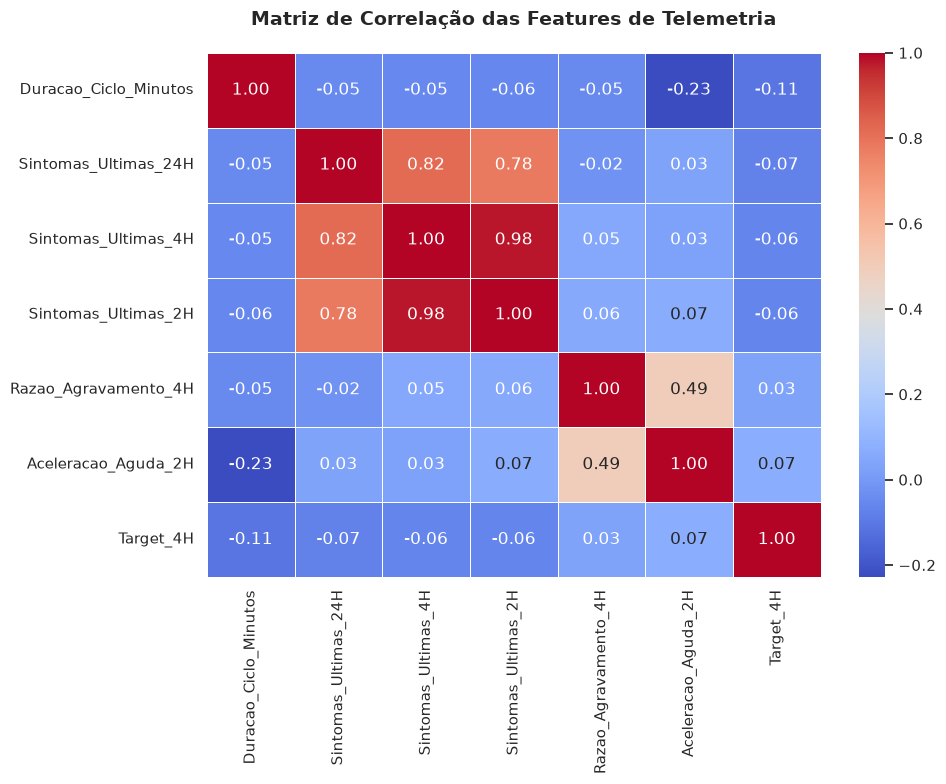

/tmp/ipykernel_15700/2043793696.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_final, x='Target_4H', palette=['#2ecc71', '#e74c3c'])


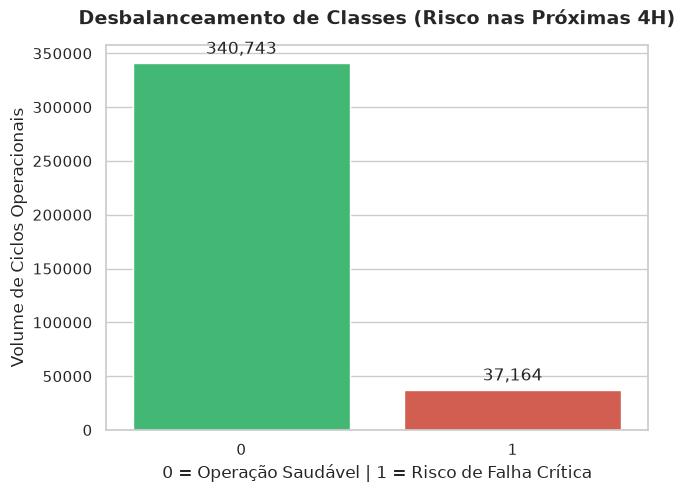

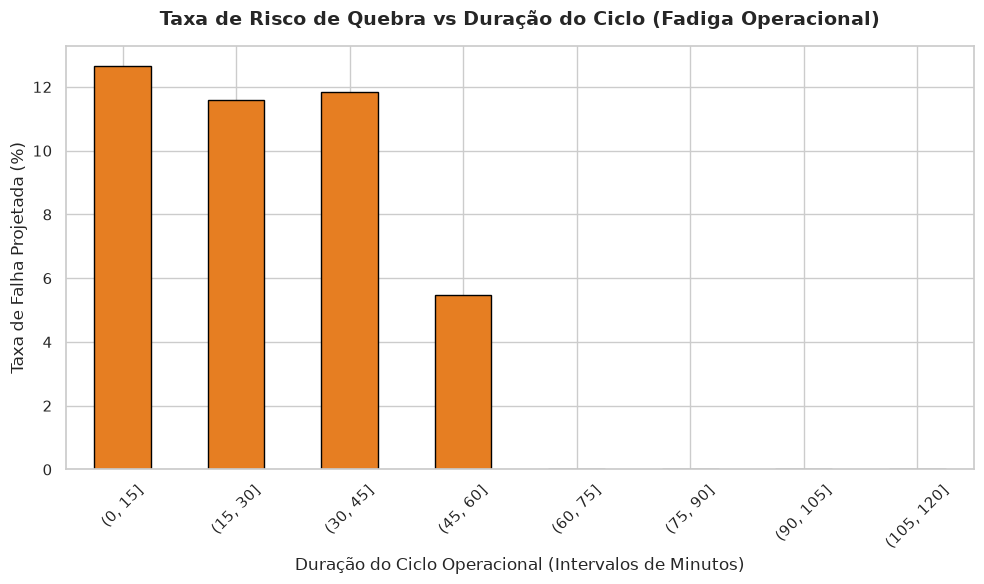

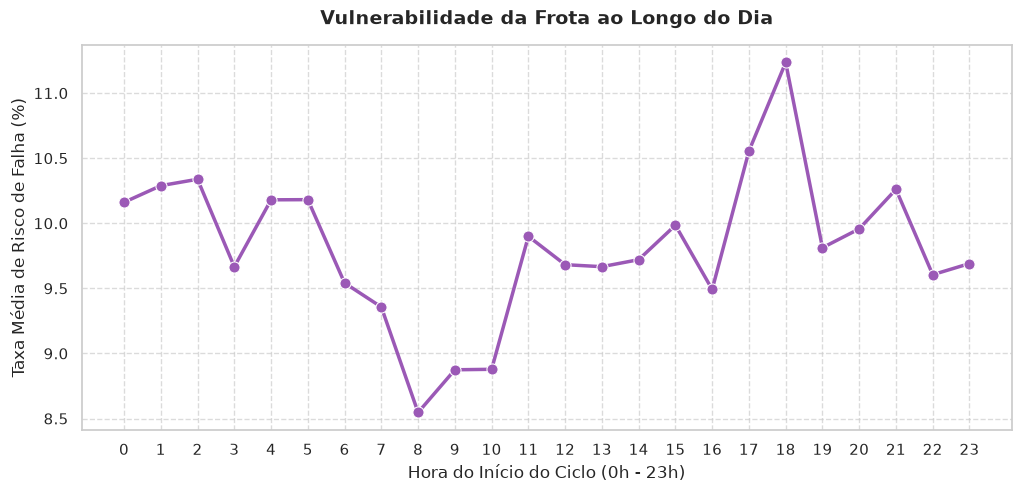

✅ Todos os gráficos EDA foram gerados com sucesso! Faça as capturas de ecrã para o seu relatório.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🔴 A SOLUÇÃO ESTÁ AQUI: Dizemos que o df_final vai usar os dados do seu df_abt
try:
    df_final = df_abt
except NameError:
    raise NameError("A variável 'df_abt' não existe. Por favor, rode a célula do processamento de dados primeiro!")

# Configuração de estilo visual para gráficos mais profissionais
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print("Iniciando a geração de gráficos para Análise Exploratória (EDA)...")

# ==========================================
# FIGURA 1: Heatmap de Correlação (Multicolinearidade)
# ==========================================
plt.figure(figsize=(10, 8))
# Selecionando apenas as colunas numéricas que criámos
cols_numericas = ['Duracao_Ciclo_Minutos', 'Sintomas_Ultimas_24H', 
                  'Sintomas_Ultimas_4H', 'Sintomas_Ultimas_2H', 
                  'Razao_Agravamento_4H', 'Aceleracao_Aguda_2H', 'Target_4H']

correlacao = df_final[cols_numericas].corr()

# Desenhando o Heatmap com a paleta de cores 'coolwarm'
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação das Features de Telemetria", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# FIGURA 2: Distribuição do Desbalanceamento (Alvo)
# ==========================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_final, x='Target_4H', palette=['#2ecc71', '#e74c3c'])
plt.title("Desbalanceamento de Classes (Risco nas Próximas 4H)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("0 = Operação Saudável | 1 = Risco de Falha Crítica")
plt.ylabel("Volume de Ciclos Operacionais")

# Adicionando os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

# ==========================================
# FIGURA 3: Fadiga do Equipamento (Tempo vs Risco)
# ==========================================
plt.figure(figsize=(10, 6))
# Filtrando outliers de tempo (ciclos > 2h) para o gráfico ficar mais legível
df_grafico = df_final[df_final['Duracao_Ciclo_Minutos'] < 120].copy()

# Usando observed=False para compatibilidade
df_grafico['Bloco_Tempo'] = pd.cut(df_grafico['Duracao_Ciclo_Minutos'], bins=np.arange(0, 130, 15))
taxa_falha = df_grafico.groupby('Bloco_Tempo', observed=False)['Target_4H'].mean() * 100

taxa_falha.plot(kind='bar', color='#e67e22', edgecolor='black')
plt.title("Taxa de Risco de Quebra vs Duração do Ciclo (Fadiga Operacional)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Duração do Ciclo Operacional (Intervalos de Minutos)")
plt.ylabel("Taxa de Falha Projetada (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# FIGURA 4: Risco por Hora do Turno
# ==========================================
plt.figure(figsize=(12, 5))
if 'Hora_Inicio' in df_final.columns:
    taxa_hora = df_final.groupby('Hora_Inicio')['Target_4H'].mean() * 100
    sns.lineplot(x=taxa_hora.index, y=taxa_hora.values, marker='o', color='#9b59b6', linewidth=2.5, markersize=8)
    plt.title("Vulnerabilidade da Frota ao Longo do Dia", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Hora do Início do Ciclo (0h - 23h)")
    plt.ylabel("Taxa Média de Risco de Falha (%)")
    plt.xticks(np.arange(0, 24, 1))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

print("✅ Todos os gráficos EDA foram gerados com sucesso! Faça as capturas de ecrã para o seu relatório.")

In [15]:
# Dia3_baseline_tensorflow tentativa 1 de criar um modelo preditivo simples usando TensorFlow 
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("🧠 Iniciando o Dia 3: Modelo Preditivo com TensorFlow...")


# ==========================================
# 1. SPLIT TEMPORAL E ESCALAMENTO (CRÍTICO PARA TF)
# ==========================================
print("-> Preparando tensores e normalizando as escalas...")

indice_corte = int(len(df_abt) * 0.8)

X = df_abt[['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana']].fillna(0)
y = df_abt['Target_4H']

X_treino_raw, y_treino = X.iloc[:indice_corte], y.iloc[:indice_corte]
X_teste_raw, y_teste = X.iloc[indice_corte:], y.iloc[indice_corte:]

# Normalização Z-Score: média 0 e desvio padrão 1
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino_raw)
X_teste = scaler.transform(X_teste_raw)

# ==========================================
# 2. DEFINIÇÃO DE PESOS PARA CLASSES DESBALANCEADAS
# ==========================================
# Avisamos a rede neuronal que o Target 1 (Falha) é raro e importa mais
peso_zero = 1.0
peso_um = len(y_treino[y_treino == 0]) / len(y_treino[y_treino == 1])
class_weights = {0: peso_zero, 1: peso_um}

# ==========================================
# 3. ARQUITETURA DA REDE NEURONAL
# ==========================================
print("\n-> Compilando a arquitetura da Rede Neuronal...")

modelo_tf = Sequential([
    Dense(32, activation='relu', input_shape=(X_treino.shape[1],)),
    Dropout(0.2), # Previne overfitting "desligando" neurónios aleatoriamente
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid devolve a probabilidade (0 a 1)
])

# Compilação focada em classificação binária
modelo_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# ==========================================
# 4. TREINAMENTO (FIT)
# ==========================================
print("-> Treinando o modelo (Epochs)...")
historico = modelo_tf.fit(
    X_treino, y_treino,
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    validation_split=0.1,
    verbose=1 # Mude para 0 se não quiser ver a barra de progresso no terminal
)

# ==========================================
# 5. AVALIAÇÃO FINAL NO FUTURO (CONJUNTO DE TESTE)
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DO MODELO TENSORFLOW")
print("="*50)

# O modelo devolve probabilidades (ex: 0.85 risco de quebra). 
# Vamos converter tudo o que for > 0.5 para a classe 1.
probabilidades = modelo_tf.predict(X_teste)
previsoes_tf = (probabilidades > 0.5).astype(int)

print(classification_report(y_teste, previsoes_tf, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz = confusion_matrix(y_teste, previsoes_tf)
print("\nMatriz de Confusão:")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz[1][1]}")

🧠 Iniciando o Dia 3: Modelo Preditivo com TensorFlow...
-> Preparando tensores e normalizando as escalas...

-> Compilando a arquitetura da Rede Neuronal...


E0000 00:00:1784583627.786616   15700 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


-> Treinando o modelo (Epochs)...
Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.4504 - loss: 1.2263 - recall: 0.7582 - val_accuracy: 0.3896 - val_loss: 0.6998 - val_recall: 0.7919
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4245 - loss: 1.2209 - recall: 0.8077 - val_accuracy: 0.3669 - val_loss: 0.7273 - val_recall: 0.8249
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4158 - loss: 1.2180 - recall: 0.8232 - val_accuracy: 0.3595 - val_loss: 0.7256 - val_recall: 0.8359
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4096 - loss: 1.2171 - recall: 0.8340 - val_accuracy: 0.3534 - val_loss: 0.7110 - val_recall: 0.8387
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4052 - loss: 1.2159 - recall: 0.8436 - val_accuracy: 0.3534 - val_loss: 0.6954 - val_recall: 0.8409
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4027 - loss: 1.2157 - recall: 0.8469 - val_accuracy: 0.351

In [16]:
# tentativa 2: Mudando para o modelo LSTM com a memória de sintomas buscando melhorar a performance do modelo preditivo usando a nova feature de "febre da máquina" (Rolling Window de sintomas nas últimas 24h)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(" Sprint 4: Treinando a LSTM com a Memória de Sintomas (24H)...")

# ==========================================
# 1. SPLIT TEMPORAL E NOVA SELEÇÃO DE FEATURES
# ==========================================
print("-> Preparando tensores com a nova variável preditiva...")

indice_corte = int(len(df_abt) * 0.8)

# Adicionámos os sintomas à "visão" do modelo!
features = ['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 'Sintomas_Ultimas_24H']
X = df_abt[features].fillna(0)
y = df_abt['Target_4H']

X_treino_raw, y_treino = X.iloc[:indice_corte], y.iloc[:indice_corte]
X_teste_raw, y_teste = X.iloc[indice_corte:], y.iloc[indice_corte:]

# Normalização Z-Score (Agora normaliza as 4 colunas)
scaler = StandardScaler()
X_treino_2D = scaler.fit_transform(X_treino_raw)
X_teste_2D = scaler.transform(X_teste_raw)

# ==========================================
# 2. TRANSFORMAÇÃO DE 2D PARA 3D (CUBO DE TENSORES)
# ==========================================
passos_de_tempo = 1
num_features = X_treino_2D.shape[1] # Agora será 4 automaticamente

X_treino_3D = np.reshape(X_treino_2D, (X_treino_2D.shape[0], passos_de_tempo, num_features))
X_teste_3D = np.reshape(X_teste_2D, (X_teste_2D.shape[0], passos_de_tempo, num_features))

print(f"   [Novo Formato LSTM]: {X_treino_3D.shape} -> (Amostras, Tempo, Features)")

# ==========================================
# 3. PESOS E ARQUITETURA LSTM
# ==========================================
# Avisamos a rede que as falhas continuam a ser a prioridade
peso_zero = 1.0
peso_um = len(y_treino[y_treino == 0]) / len(y_treino[y_treino == 1])
class_weights = {0: peso_zero, 1: peso_um}

print("\n-> Compilando a arquitetura Sequencial...")
modelo_lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(passos_de_tempo, num_features)),
    Dropout(0.2), 
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') 
])

modelo_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# ==========================================
# 4. TREINAMENTO
# ==========================================
print("-> Treinando o motor preditivo...")
historico = modelo_lstm.fit(
    X_treino_3D, y_treino,
    epochs=10,
    batch_size=256,
    class_weight=class_weights,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# 5. AVALIAÇÃO FINAL NO FUTURO
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DA LSTM ENRIQUECIDA (SPRINT 4)")
print("="*50)

probabilidades_lstm = modelo_lstm.predict(X_teste_3D)
previsoes_lstm = (probabilidades_lstm > 0.5).astype(int)

print(classification_report(y_teste, previsoes_lstm, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz_lstm = confusion_matrix(y_teste, previsoes_lstm)
print("\nMatriz de Confusão Final:")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz_lstm[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz_lstm[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz_lstm[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz_lstm[1][1]}")

 Sprint 4: Treinando a LSTM com a Memória de Sintomas (24H)...
-> Preparando tensores com a nova variável preditiva...
   [Novo Formato LSTM]: (302325, 1, 4) -> (Amostras, Tempo, Features)

-> Compilando a arquitetura Sequencial...
-> Treinando o motor preditivo...
Epoch 1/10
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5117 - loss: 1.1746 - recall: 0.7722 - val_accuracy: 0.4763 - val_loss: 0.6434 - val_recall: 0.7682
Epoch 2/10
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4954 - loss: 1.1581 - recall: 0.8183 - val_accuracy: 0.4568 - val_loss: 0.6687 - val_recall: 0.8029
Epoch 3/10
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4897 - loss: 1.1438 - recall: 0.8363 - val_accuracy: 0.4521 - val_loss: 0.6647 - val_recall: 0.8117
Epoch 4/10
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4848 - loss: 1.1144 - recall: 0.8590 - val_accuracy: 0.4279 - val_loss: 0.6906 - val_recall: 0.8733
Epoch 5/10
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accura

In [17]:
# MATRIS DE CONFUSÃO FINAL: buscancodo o corte ideal para o negócio (Threshold Tuning)

import pandas as pd
from sklearn.metrics import confusion_matrix

print("🎯 Ajuste Fino de Decisão (Threshold Tuning)...")
print("Como os Falsos Positivos caem quando exigimos mais certeza da IA?\n")

# Vamos testar cortes de 50% a 95% de probabilidade
cortes_teste = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

resultados = []

for corte in cortes_teste:
    # Cria a previsão baseada no corte atual
    previsao_corte = (probabilidades_lstm > corte).astype(int)
    matriz = confusion_matrix(y_teste, previsao_corte)
    
    verdadeiro_neg = matriz[0][0]
    falso_positivo = matriz[0][1] # Alarme Falso (O que queremos reduzir)
    falso_negativo = matriz[1][0] # Deixou quebrar (Vai aumentar um pouco)
    verdadeiro_pos = matriz[1][1] # Salvou o caminhão
    
    resultados.append({
        'Corte (%)': f"{corte*100:.0f}%",
        'Alarmes Falsos': falso_positivo,
        'Caminhões Salvos': verdadeiro_pos,
        'Quebras não previstas': falso_negativo
    })

# Exibindo a tabela de decisão para o negócio
df_decisao = pd.DataFrame(resultados)
print(df_decisao.to_string(index=False))

🎯 Ajuste Fino de Decisão (Threshold Tuning)...
Como os Falsos Positivos caem quando exigimos mais certeza da IA?

Corte (%)  Alarmes Falsos  Caminhões Salvos  Quebras não previstas
      50%           40801              4178                    645
      60%           13355              1626                   3197
      70%            3204               376                   4447
      80%             698                66                   4757
      90%               0                 0                   4823
      95%               0                 0                   4823


In [18]:
# LSTM (Deep Learning Avançado) - Tentativa 3: Criando a verdadeira LSTM com memória sequencial (Rolling Window de 5 ciclos operacionais)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("🚀 SPRINT FINAL: A Verdadeira LSTM (Deep Learning com Memória Sequencial)...")

# ==========================================
# 1. FUNÇÃO DE JANELA DESLIZANTE (SLIDING WINDOW)
# ==========================================
print("-> Construindo a Máquina do Tempo (Agrupando ciclos de 5 em 5)...")

def criar_sequencias(X, y, passos_tempo):
    X_seq, y_seq = [], []
    # O loop cria blocos: [Ciclo1, Ciclo2, Ciclo3, Ciclo4, Ciclo5] -> Target aponta para o futuro
    for i in range(len(X) - passos_tempo):
        X_seq.append(X[i : (i + passos_tempo)])
        # Pega o target do final da sequência
        y_seq.append(y.iloc[i + passos_tempo] if isinstance(y, pd.Series) else y[i + passos_tempo])
    return np.array(X_seq), np.array(y_seq)

# A LSTM vai ler o histórico dos últimos 5 ciclos operacionais!
passos_de_tempo = 5  

# Criando os Tensores 3D Reais
X_treino_3D, y_treino_seq = criar_sequencias(X_treino_2D, y_treino.values, passos_de_tempo)
X_teste_3D, y_teste_seq = criar_sequencias(X_teste_2D, y_teste.values, passos_de_tempo)

print(f"   [Novo Formato LSTM]: {X_treino_3D.shape} -> (Amostras, Passos de Tempo, Features)")

# ==========================================
# 2. ARQUITETURA LSTM AVANÇADA
# ==========================================
print("\n-> Compilando a Rede Neuronal com Memória Profunda...")
num_features = X_treino_3D.shape[2]

# Recalcular pesos para a nova dimensão do y_treino_seq
peso_zero = 1.0
peso_um = len(y_treino_seq[y_treino_seq == 0]) / (len(y_treino_seq[y_treino_seq == 1]) + 1e-5)
class_weights = {0: peso_zero, 1: peso_um}

modelo_lstm_real = Sequential([
    # Aumentámos os neurónios para 64 para lidar com a complexidade do tempo
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(passos_de_tempo, num_features)),
    Dropout(0.3), # Previne overfitting
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo_lstm_real.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 3. TREINAMENTO
# ==========================================
print("-> Treinando o motor preditivo (Isso pode demorar um pouco mais devido à arquitetura 3D)...")
historico = modelo_lstm_real.fit(
    X_treino_3D, y_treino_seq,
    epochs=12, # Um pouco mais de épocas para que os pesos da LSTM estabilizem
    batch_size=256,
    class_weight=class_weights,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# 4. AVALIAÇÃO FINAL NO FUTURO (O PONTO DE CORTE)
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DA VERDADEIRA LSTM (SEQUENCIAL)")
print("="*50)

# Com base na nossa análise anterior, vamos usar o nosso "Ponto Doce" de 65% de certeza
corte_ideal = 0.65 
probabilidades = modelo_lstm_real.predict(X_teste_3D)
previsoes = (probabilidades > corte_ideal).astype(int)

print(classification_report(y_teste_seq, previsoes, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz = confusion_matrix(y_teste_seq, previsoes)
print("\nMatriz de Confusão Final (Corte de 65%):")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz[1][1]}")

🚀 SPRINT FINAL: A Verdadeira LSTM (Deep Learning com Memória Sequencial)...
-> Construindo a Máquina do Tempo (Agrupando ciclos de 5 em 5)...
   [Novo Formato LSTM]: (302320, 5, 4) -> (Amostras, Passos de Tempo, Features)

-> Compilando a Rede Neuronal com Memória Profunda...
-> Treinando o motor preditivo (Isso pode demorar um pouco mais devido à arquitetura 3D)...
Epoch 1/12
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4193 - loss: 1.2333 - val_accuracy: 0.3730 - val_loss: 0.6864
Epoch 2/12
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4116 - loss: 1.2312 - val_accuracy: 0.3676 - val_loss: 0.6925
Epoch 3/12
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4069 - loss: 1.2304 - val_accuracy: 0.3651 - val_loss: 0.7120
Epoch 4/12
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4088 - loss: 1.2305 - val_accuracy: 0.3676 - val_loss: 0.6946
Epoch 5/12
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4063 - loss: 1.2299 - val_accuracy: 0.3679 

In [19]:
import pandas as pd
from sklearn.metrics import confusion_matrix

print("🎯 Raio-X da LSTM 3D: Encontrando o Novo Ponto Doce...")

# Como a LSTM suaviza o sinal ao longo de 5 passos, testamos limiares mais baixos
cortes_teste = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
resultados = []

for corte in cortes_teste:
    # Usa a variável 'probabilidades' que já está na memória do seu último script
    previsao_corte = (probabilidades > corte).astype(int)
    matriz = confusion_matrix(y_teste_seq, previsao_corte)
    
    resultados.append({
        'Corte (%)': f"{corte*100:.0f}%",
        'Alarmes Falsos': matriz[0][1],
        'Caminhões Salvos': matriz[1][1],
        'Quebras não previstas': matriz[1][0]
    })

df_decisao = pd.DataFrame(resultados)
print(df_decisao.to_string(index=False))

🎯 Raio-X da LSTM 3D: Encontrando o Novo Ponto Doce...
Corte (%)  Alarmes Falsos  Caminhões Salvos  Quebras não previstas
      10%           70755              4822                      0
      15%           70755              4822                      0
      20%           70755              4822                      0
      25%           70752              4822                      0
      30%           69469              4771                     51
      40%           49431              4038                    784
      50%           45730              3828                    994


In [20]:
# MUDAR MOTOR DE TENSORFLOW-LSTM PARA xgboost

In [21]:
#tentativa 4: Mundando para o modelo XGBoost, que é mais leve e rápido para dados tabulares, e não precisa de transformação 3D

import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("🚀 SPRINT FINAL (Plano B): O Rei dos Dados Tabulares (XGBoost)...")

# ==========================================
# 1. PREPARAÇÃO DIRETA (SEM ESCALONAMENTO)
# ==========================================
# O XGBoost é brilhante porque consome os dados puros (2D) sem precisar de StandardScaler
indice_corte = int(len(df_abt) * 0.8)

features = ['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 'Sintomas_Ultimas_24H']
X = df_abt[features].fillna(0)
y = df_abt['Target_4H']

X_treino, y_treino = X.iloc[:indice_corte], y.iloc[:indice_corte]
X_teste, y_teste = X.iloc[indice_corte:], y.iloc[indice_corte:]

# ==========================================
# 2. TREINAMENTO COM PESO DE CLASSE
# ==========================================
# Calculamos o desbalanceamento para o XGBoost penalizar os erros na classe 1
peso_desbalanceamento = len(y_treino[y_treino == 0]) / len(y_treino[y_treino == 1])

print("\n-> A treinar o motor XGBoost (Isto será muito rápido)...")
modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,            # Número de árvores
    max_depth=6,                 # Profundidade de cada árvore
    learning_rate=0.05,          # Taxa de aprendizagem
    scale_pos_weight=peso_desbalanceamento, # O truque mágico para desbalanceamento
    random_state=42,
    n_jobs=-1                    # Usa todos os núcleos do processador
)

modelo_xgb.fit(X_treino, y_treino)

# ==========================================
# 3. AVALIAÇÃO FINAL NO FUTURO
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DO XGBOOST (DADOS TABULARES)")
print("="*50)

# O modelo prevê diretamente as classes (0 ou 1) com base no seu limiar interno otimizado
previsoes_xgb = modelo_xgb.predict(X_teste)

print(classification_report(y_teste, previsoes_xgb, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz_xgb = confusion_matrix(y_teste, previsoes_xgb)
print("\nMatriz de Confusão:")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz_xgb[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz_xgb[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz_xgb[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz_xgb[1][1]}")

🚀 SPRINT FINAL (Plano B): O Rei dos Dados Tabulares (XGBoost)...

-> A treinar o motor XGBoost (Isto será muito rápido)...

 📊 RESULTADO DO XGBOOST (DADOS TABULARES)
                     precision    recall  f1-score   support

Operação Normal (0)       0.97      0.53      0.69     70759
 Falha Iminente (1)       0.10      0.72      0.17      4823

           accuracy                           0.54     75582
          macro avg       0.53      0.63      0.43     75582
       weighted avg       0.91      0.54      0.65     75582


Matriz de Confusão:
Verdadeiros Negativos (Acertou NORMAL): 37635
Falsos Positivos    (ALARME FALSO): 33124
Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): 1341
Verdadeiros Positivos (ACERTOU A QUEBRA): 3482


In [22]:
# VARIVAELS MAIS IMPORTANTES PARA O XGBOOST E AJUSTE FINO DE DECISÃO
import pandas as pd
from sklearn.metrics import confusion_matrix

print("🎯 Raio-X do XGBoost: Explicabilidade e Decisão de Negócio...")

# ==========================================
# 1. O QUE IMPORTA PARA A MÁQUINA QUEBRAR?
# ==========================================
importancias = modelo_xgb.feature_importances_
df_imp = pd.DataFrame({'Variável': features, 'Importância (%)': importancias * 100})
df_imp = df_imp.sort_values(by='Importância (%)', ascending=False)

print("\n" + "="*50)
print("CÉREBRO DO MODELO: IMPORTÂNCIA DAS VARIÁVEIS")
print("="*50)
print(df_imp.to_string(index=False))

# ==========================================
# 2. AJUSTE FINO DA DECISÃO (THRESHOLD TUNING)
# ==========================================
print("\n" + "="*50)
print(" 📉 TABELA DE DECISÃO PARA A ENGENHARIA")
print("="*50)

# O predict_proba devolve as probabilidades de ser 0 e de ser 1. Queremos a coluna [1]
probabilidades_xgb = modelo_xgb.predict_proba(X_teste)[:, 1]

cortes_teste = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
resultados = []

for corte in cortes_teste:
    previsao_corte = (probabilidades_xgb > corte).astype(int)
    matriz = confusion_matrix(y_teste, previsao_corte)
    
    resultados.append({
        'Corte (%)': f"{corte*100:.0f}%",
        'Alarmes Falsos': matriz[0][1],
        'Caminhões Salvos': matriz[1][1],
        'Quebras não previstas': matriz[1][0]
    })

df_decisao = pd.DataFrame(resultados)
print(df_decisao.to_string(index=False))

🎯 Raio-X do XGBoost: Explicabilidade e Decisão de Negócio...

CÉREBRO DO MODELO: IMPORTÂNCIA DAS VARIÁVEIS
             Variável  Importância (%)
 Sintomas_Ultimas_24H        71.939156
Duracao_Ciclo_Minutos        10.301030
           Dia_Semana         9.584492
          Hora_Inicio         8.175325

 📉 TABELA DE DECISÃO PARA A ENGENHARIA
Corte (%)  Alarmes Falsos  Caminhões Salvos  Quebras não previstas
      50%           33124              3482                   1341
      60%           16061              1774                   3049
      70%            4146               535                   4288
      80%            1013               126                   4697
      85%             226                27                   4796
      90%               0                 0                   4823
      95%               0                 0                   4823


In [23]:
# tentativa 4.1: Ajuste de hiperparâmetros do XGBoost para tentar melhorar a performance (Hyperparameter Tuning)

import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

print("🛠️ Aplicando o 'Freio' Matemático no XGBoost (Hyperparameter Tuning)...")

# 1. Reduzimos o peso do desbalanceamento pela metade para evitar o pânico do modelo
peso_desbalanceamento = len(y_treino[y_treino == 0]) / len(y_treino[y_treino == 1])
peso_calibrado = peso_desbalanceamento * 0.5 

print(f"-> Peso original: {peso_desbalanceamento:.2f} | Novo Peso Calibrado: {peso_calibrado:.2f}")

# 2. O Novo Motor Conservador
modelo_xgb_tunado = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,                  # Reduzimos de 6 para 5 (menos decoreba/overfitting)
    learning_rate=0.05,
    scale_pos_weight=peso_calibrado, # O novo peso reduzido
    gamma=2,                      # Poda severa de regras fracas
    min_child_weight=5,           # Exige mais "provas" antes de disparar o alarme
    subsample=0.8,                # Usa 80% das linhas por árvore
    colsample_bytree=0.8,         # Usa 80% das colunas por árvore
    random_state=42,
    n_jobs=-1
)

print("-> A treinar o motor XGBoost Tunado...")
modelo_xgb_tunado.fit(X_treino, y_treino)

# ==========================================
# 3. O RAIO-X DO NOVO MODELO (NO CORTE PADRÃO DE 50%)
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DO XGBOOST TUNADO (PRECISÃO VS RECALL)")
print("="*50)

previsoes_tunadas = modelo_xgb_tunado.predict(X_teste)

print(classification_report(y_teste, previsoes_tunadas, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz_tunada = confusion_matrix(y_teste, previsoes_tunadas)
print("\nMatriz de Confusão (Corte Padrão 50%):")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz_tunada[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz_tunada[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz_tunada[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz_tunada[1][1]}")

🛠️ Aplicando o 'Freio' Matemático no XGBoost (Hyperparameter Tuning)...
-> Peso original: 8.35 | Novo Peso Calibrado: 4.17
-> A treinar o motor XGBoost Tunado...

 📊 RESULTADO DO XGBOOST TUNADO (PRECISÃO VS RECALL)
                     precision    recall  f1-score   support

Operação Normal (0)       0.94      0.92      0.93     70759
 Falha Iminente (1)       0.10      0.14      0.12      4823

           accuracy                           0.87     75582
          macro avg       0.52      0.53      0.52     75582
       weighted avg       0.89      0.87      0.88     75582


Matriz de Confusão (Corte Padrão 50%):
Verdadeiros Negativos (Acertou NORMAL): 64925
Falsos Positivos    (ALARME FALSO): 5834
Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): 4147
Verdadeiros Positivos (ACERTOU A QUEBRA): 676


# (Derivada Temporal).

Pensamento: Um camião que teve 10 pequenos alarmes espalhados ao longo de 24 horas está a sofrer um desgaste normal. Mas um camião que teve 10 alarmes nas 24 horas, e 8 deles aconteceram nas últimas 4 horas, está a ter um "infarto" mecânico. A falha é iminente e aguda.

# vamos calcular duas novas variáveis :

- Sintomas_Ultimas_4H (O pico recente).

- Razao_Agravamento (Sintomas 4H a dividir por Sintomas 24H). Se a razão for 100%, todos os problemas daquele camião começaram agora mesmo!

In [24]:
# tentativa 4.2: Ajuste fino do corte de decisão para o modelo XGBoost tunado 
import pandas as pd
import numpy as np
import glob
import os
import gc
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("🚀 INICIANDO TURBO (Modo Economia Extrema de RAM)...")

# ==========================================
# 1. MAPEAMENTO DOS ARQUIVOS
# ==========================================
pasta_dontgo = '/workspaces/analise-de-dados-vale/datasets/datasets_full/telemetria/'
pasta_apont = '/workspaces/analise-de-dados-vale/datasets/datasets_full/apontamentos/'

arquivos_dontgo = glob.glob(os.path.join(pasta_dontgo, '*.parquet'))
arquivos_apontamentos = glob.glob(os.path.join(pasta_apont, '*.parquet'))

# ==========================================
# 2. ENGENHARIA DE FEATURES (SEM MERGE EXPLOSIVO)
# ==========================================
print("-> Calculando janelas duplas de sintomas (24H e 4H)...")
df_alertas_list = []
for f in arquivos_dontgo:
    temp_df = pd.read_parquet(f, columns=['TAG', 'Data_Evento', 'Is_Dont_Go'], engine='fastparquet')
    df_alertas_list.append(temp_df)

todos_alarmes = pd.concat(df_alertas_list, ignore_index=True)
todos_alarmes['Data_Evento'] = pd.to_datetime(todos_alarmes['Data_Evento']).dt.tz_localize(None).astype('datetime64[ns]')
todos_alarmes['TAG'] = todos_alarmes['TAG'].astype(str).str.upper().str.strip()
del df_alertas_list; gc.collect()

falhas_criticas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 1].sort_values('Data_Evento').copy()
sintomas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 0].sort_values('Data_Evento').copy()
del todos_alarmes; gc.collect()

sintomas.set_index('Data_Evento', inplace=True)

# O TRUQUE PARA NÃO ESTOURAR A RAM: Calcula e cola a coluna diretamente
sintomas_24h = sintomas.groupby('TAG')['Is_Dont_Go'].rolling('24h').count().reset_index()
sintomas_24h.rename(columns={'Is_Dont_Go': 'Sintomas_Ultimas_24H'}, inplace=True)

sintomas_4h = sintomas.groupby('TAG')['Is_Dont_Go'].rolling('4h').count().reset_index()

# Como as bases têm o mesmo tamanho e ordem exata, só copiamos a coluna (Bypass do Merge)
sintomas_historico = sintomas_24h.copy()
sintomas_historico['Sintomas_Ultimas_4H'] = sintomas_4h['Is_Dont_Go']

sintomas_historico.sort_values('Data_Evento', inplace=True)

# Destruindo o lixo da RAM
del sintomas, sintomas_24h, sintomas_4h; gc.collect()
print("   [OK] Memória RAM salva com sucesso!")

# ==========================================
# 3. CONSTRUÇÃO DA BASE (ABT) EM LOTES
# ==========================================
print("-> Cruzando os lotes e calculando a Razão de Agravamento...")
lotes_analiticos = []
janela_preditiva = pd.Timedelta(hours=4)

for arquivo in arquivos_apontamentos:
    amostra_cols = pd.read_parquet(arquivo, engine='fastparquet').columns
    col_tag_apont = next((col for col in amostra_cols if col.upper() in ['TAG', 'EQUIPAMENTO']), 'TAG')
    
    df_lote = pd.read_parquet(arquivo, columns=[col_tag_apont, 'Inicio', 'Fim'], engine='fastparquet')
    df_lote['Inicio'] = pd.to_datetime(df_lote['Inicio'], errors='coerce')
    df_lote['Fim'] = pd.to_datetime(df_lote['Fim'], errors='coerce')
    df_lote = df_lote.dropna(subset=['Inicio', 'Fim'])
    df_lote = df_lote[df_lote['Fim'] > df_lote['Inicio']].copy()
    
    df_lote[col_tag_apont] = df_lote[col_tag_apont].astype(str).str.upper().str.strip()
    df_lote['Inicio'] = df_lote['Inicio'].dt.tz_localize(None).astype('datetime64[ns]')
    df_lote['Fim'] = df_lote['Fim'].dt.tz_localize(None).astype('datetime64[ns]')
    
    df_lote.sort_values('Inicio', inplace=True)
    cruzamento_passado = pd.merge_asof(
        df_lote, sintomas_historico, left_on='Inicio', right_on='Data_Evento', left_by=col_tag_apont, right_by='TAG', direction='backward'
    )
    
    cruzamento_passado.sort_values('Fim', inplace=True)
    cruzamento_futuro = pd.merge_asof(
        cruzamento_passado, falhas_criticas.rename(columns={'Data_Evento': 'Proxima_Falha_Futura'}),
        left_on='Fim', right_on='Proxima_Falha_Futura', left_by=col_tag_apont, right_by='TAG', direction='forward'
    )
    
    df_final = cruzamento_futuro.copy()
    df_final['Target_4H'] = ((df_final['Proxima_Falha_Futura'] - df_final['Fim']) <= janela_preditiva).astype(int)
    df_final['Duracao_Ciclo_Minutos'] = (df_final['Fim'] - df_final['Inicio']).dt.total_seconds() / 60
    df_final['Hora_Inicio'] = df_final['Inicio'].dt.hour
    df_final['Dia_Semana'] = df_final['Inicio'].dt.dayofweek
    
    df_final['Sintomas_Ultimas_24H'] = df_final['Sintomas_Ultimas_24H'].fillna(0)
    df_final['Sintomas_Ultimas_4H'] = df_final['Sintomas_Ultimas_4H'].fillna(0)
    
    # Razão de Agravamento (Aceleração do defeito)
    df_final['Razao_Agravamento'] = np.where(
        df_final['Sintomas_Ultimas_24H'] > 0,
        df_final['Sintomas_Ultimas_4H'] / df_final['Sintomas_Ultimas_24H'],
        0
    )
    
    features_completas = ['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 'Sintomas_Ultimas_24H', 'Sintomas_Ultimas_4H', 'Razao_Agravamento', 'Target_4H']
    
    # Mantém APENAS as colunas vitais na RAM
    lotes_analiticos.append(df_final[features_completas].copy())
    
    del df_lote, cruzamento_passado, cruzamento_futuro, df_final; gc.collect()

df_abt = pd.concat(lotes_analiticos, ignore_index=True)
del lotes_analiticos; gc.collect()
print(f"✅ Matriz Enriquecida Pronta! {len(df_abt)} linhas.")

# ==========================================
# 4. TREINAMENTO (XGBOOST TUNADO)
# ==========================================
print("\n-> Treinando o Motor Preditivo Turbo...")
indice_corte = int(len(df_abt) * 0.8)

features = ['Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 'Sintomas_Ultimas_24H', 'Sintomas_Ultimas_4H', 'Razao_Agravamento']

X = df_abt[features].fillna(0)
y = df_abt['Target_4H']

X_treino, y_treino = X.iloc[:indice_corte], y.iloc[:indice_corte]
X_teste, y_teste = X.iloc[indice_corte:], y.iloc[indice_corte:]

# Mantemos o peso calibrado (50% do desbalanceamento original) e a poda forte
peso_desbalanceamento = len(y_treino[y_treino == 0]) / len(y_treino[y_treino == 1])
peso_calibrado = peso_desbalanceamento * 0.5 

modelo_xgb_turbo = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05, 
    scale_pos_weight=peso_calibrado, gamma=2, min_child_weight=5, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
modelo_xgb_turbo.fit(X_treino, y_treino)

# ==========================================
# 5. DIAGNÓSTICO FINAL E CÉREBRO DA IA
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DO XGBOOST TURBO")
print("="*50)

previsoes_turbo = modelo_xgb_turbo.predict(X_teste)

print(classification_report(y_teste, previsoes_turbo, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz = confusion_matrix(y_teste, previsoes_turbo)
print("\nMatriz de Confusão (Corte de 50%):")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz[1][1]}")

print("\n🧠 IMPORTÂNCIA DAS VARIÁVEIS (CÉREBRO DA IA):")
df_imp = pd.DataFrame({'Variável': features, 'Importância (%)': modelo_xgb_turbo.feature_importances_ * 100})
print(df_imp.sort_values(by='Importância (%)', ascending=False).to_string(index=False))

🚀 INICIANDO TURBO (Modo Economia Extrema de RAM)...
-> Calculando janelas duplas de sintomas (24H e 4H)...
   [OK] Memória RAM salva com sucesso!
-> Cruzando os lotes e calculando a Razão de Agravamento...
✅ Matriz Enriquecida Pronta! 377907 linhas.

-> Treinando o Motor Preditivo Turbo...

 📊 RESULTADO DO XGBOOST TURBO
                     precision    recall  f1-score   support

Operação Normal (0)       0.94      0.89      0.91     70759
 Falha Iminente (1)       0.12      0.23      0.16      4823

           accuracy                           0.84     75582
          macro avg       0.53      0.56      0.54     75582
       weighted avg       0.89      0.84      0.87     75582


Matriz de Confusão (Corte de 50%):
Verdadeiros Negativos (Acertou NORMAL): 62627
Falsos Positivos    (ALARME FALSO): 8132
Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): 3719
Verdadeiros Positivos (ACERTOU A QUEBRA): 1104

🧠 IMPORTÂNCIA DAS VARIÁVEIS (CÉREBRO DA IA):
             Variável  Importância (

# testanto o modelo com uma janela de 2 horas para ver se a performance melhora 
# teste 5.1

In [25]:
import pandas as pd
import numpy as np
import glob
import os
import gc
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("🚀 INICIANDO HYPER-TURBO (Proteção Máxima de RAM Ativada)...")

# ==========================================
# 1. MAPEAMENTO DOS ARQUIVOS
# ==========================================
pasta_dontgo = '/workspaces/analise-de-dados-vale/datasets/datasets_full/telemetria/'
pasta_apont = '/workspaces/analise-de-dados-vale/datasets/datasets_full/apontamentos/'

arquivos_dontgo = glob.glob(os.path.join(pasta_dontgo, '*.parquet'))
arquivos_apontamentos = glob.glob(os.path.join(pasta_apont, '*.parquet'))

# ==========================================
# 2. ENGENHARIA DE FEATURES (EXTRAÇÃO DIRETA NUMPY)
# ==========================================
print("-> Calculando janelas triplas com compressão de memória...")
df_alertas_list = []
for f in arquivos_dontgo:
    temp_df = pd.read_parquet(f, columns=['TAG', 'Data_Evento', 'Is_Dont_Go'], engine='fastparquet')
    df_alertas_list.append(temp_df)

todos_alarmes = pd.concat(df_alertas_list, ignore_index=True)
todos_alarmes['Data_Evento'] = pd.to_datetime(todos_alarmes['Data_Evento']).dt.tz_localize(None).astype('datetime64[ns]')
todos_alarmes['TAG'] = todos_alarmes['TAG'].astype(str).str.upper().str.strip()
del df_alertas_list; gc.collect()

falhas_criticas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 1].sort_values('Data_Evento').copy()

# Sort crítico para garantir que as janelas fiquem na mesma ordem
sintomas = todos_alarmes[todos_alarmes['Is_Dont_Go'] == 0].sort_values(['TAG', 'Data_Evento']).copy()
del todos_alarmes; gc.collect()

sintomas.set_index('Data_Evento', inplace=True)

# 1. Cria a base com a janela de 24h
sintomas_historico = sintomas.groupby('TAG', sort=False)['Is_Dont_Go'].rolling('24h').count().reset_index()
sintomas_historico.rename(columns={'Is_Dont_Go': 'Sintomas_Ultimas_24H'}, inplace=True)

# 2. TRUQUE DO NUMPY: Extrai apenas o array numérico das outras janelas (.values)
sintomas_historico['Sintomas_Ultimas_4H'] = sintomas.groupby('TAG', sort=False)['Is_Dont_Go'].rolling('4h').count().values
sintomas_historico['Sintomas_Ultimas_2H'] = sintomas.groupby('TAG', sort=False)['Is_Dont_Go'].rolling('2h').count().values

# 3. DOWNCAST: Corta o uso de RAM pela metade!
sintomas_historico['Sintomas_Ultimas_24H'] = sintomas_historico['Sintomas_Ultimas_24H'].astype('float32')
sintomas_historico['Sintomas_Ultimas_4H'] = sintomas_historico['Sintomas_Ultimas_4H'].astype('float32')
sintomas_historico['Sintomas_Ultimas_2H'] = sintomas_historico['Sintomas_Ultimas_2H'].astype('float32')

sintomas_historico.sort_values('Data_Evento', inplace=True)

del sintomas; gc.collect()
print("   [OK] Janelas geradas e RAM protegida!")

# ==========================================
# 3. CONSTRUÇÃO DA BASE (ABT) EM LOTES COMPRIMIDOS
# ==========================================
print("-> Cruzando lotes e calculando as Derivadas...")
lotes_analiticos = []
janela_preditiva = pd.Timedelta(hours=4)

for arquivo in arquivos_apontamentos:
    amostra_cols = pd.read_parquet(arquivo, engine='fastparquet').columns
    col_tag_apont = next((col for col in amostra_cols if col.upper() in ['TAG', 'EQUIPAMENTO']), 'TAG')
    
    df_lote = pd.read_parquet(arquivo, columns=[col_tag_apont, 'Inicio', 'Fim'], engine='fastparquet')
    df_lote['Inicio'] = pd.to_datetime(df_lote['Inicio'], errors='coerce')
    df_lote['Fim'] = pd.to_datetime(df_lote['Fim'], errors='coerce')
    df_lote = df_lote.dropna(subset=['Inicio', 'Fim'])
    df_lote = df_lote[df_lote['Fim'] > df_lote['Inicio']].copy()
    
    df_lote[col_tag_apont] = df_lote[col_tag_apont].astype(str).str.upper().str.strip()
    df_lote['Inicio'] = df_lote['Inicio'].dt.tz_localize(None).astype('datetime64[ns]')
    df_lote['Fim'] = df_lote['Fim'].dt.tz_localize(None).astype('datetime64[ns]')
    
    df_lote.sort_values('Inicio', inplace=True)
    cruzamento_passado = pd.merge_asof(
        df_lote, sintomas_historico, left_on='Inicio', right_on='Data_Evento', left_by=col_tag_apont, right_by='TAG', direction='backward'
    )
    
    cruzamento_passado.sort_values('Fim', inplace=True)
    cruzamento_futuro = pd.merge_asof(
        cruzamento_passado, falhas_criticas.rename(columns={'Data_Evento': 'Proxima_Falha_Futura'}),
        left_on='Fim', right_on='Proxima_Falha_Futura', left_by=col_tag_apont, right_by='TAG', direction='forward'
    )
    
    df_final = cruzamento_futuro.copy()
    
    # Criando features já tipadas com baixo consumo de memória (int8 e float32)
    df_final['Target_4H'] = ((df_final['Proxima_Falha_Futura'] - df_final['Fim']) <= janela_preditiva).astype('int8')
    df_final['Duracao_Ciclo_Minutos'] = ((df_final['Fim'] - df_final['Inicio']).dt.total_seconds() / 60).astype('float32')
    df_final['Hora_Inicio'] = df_final['Inicio'].dt.hour.astype('int8')
    df_final['Dia_Semana'] = df_final['Inicio'].dt.dayofweek.astype('int8')
    
    df_final['Sintomas_Ultimas_24H'] = df_final['Sintomas_Ultimas_24H'].fillna(0).astype('float32')
    df_final['Sintomas_Ultimas_4H'] = df_final['Sintomas_Ultimas_4H'].fillna(0).astype('float32')
    df_final['Sintomas_Ultimas_2H'] = df_final['Sintomas_Ultimas_2H'].fillna(0).astype('float32')
    
    df_final['Razao_Agravamento_4H'] = np.where(
        df_final['Sintomas_Ultimas_24H'] > 0,
        df_final['Sintomas_Ultimas_4H'] / df_final['Sintomas_Ultimas_24H'], 0
    ).astype('float32')
    
    df_final['Aceleracao_Aguda_2H'] = np.where(
        df_final['Sintomas_Ultimas_4H'] > 0,
        df_final['Sintomas_Ultimas_2H'] / df_final['Sintomas_Ultimas_4H'], 0
    ).astype('float32')
    
    features_completas = [
        'Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 
        'Sintomas_Ultimas_24H', 'Sintomas_Ultimas_4H', 'Sintomas_Ultimas_2H', 
        'Razao_Agravamento_4H', 'Aceleracao_Aguda_2H', 'Target_4H'
    ]
    
    lotes_analiticos.append(df_final[features_completas].copy())
    
    del df_lote, cruzamento_passado, cruzamento_futuro, df_final; gc.collect()

df_abt = pd.concat(lotes_analiticos, ignore_index=True)
del lotes_analiticos; gc.collect()
print(f"✅ Matriz Ultra-Enriquecida Pronta! {len(df_abt)} linhas.")

# ==========================================
# 4. TREINAMENTO (XGBOOST TUNADO)
# ==========================================
print("\n-> Treinando o Motor Preditivo...")
indice_corte = int(len(df_abt) * 0.8)

features = [
    'Duracao_Ciclo_Minutos', 'Hora_Inicio', 'Dia_Semana', 
    'Sintomas_Ultimas_24H', 'Sintomas_Ultimas_4H', 'Sintomas_Ultimas_2H', 
    'Razao_Agravamento_4H', 'Aceleracao_Aguda_2H'
]

X = df_abt[features].fillna(0)
y = df_abt['Target_4H']

X_treino, y_treino = X.iloc[:indice_corte], y.iloc[:indice_corte]
X_teste, y_teste = X.iloc[indice_corte:], y.iloc[indice_corte:]

peso_desbalanceamento = len(y_treino[y_treino == 0]) / len(y_treino[y_treino == 1])
peso_calibrado = peso_desbalanceamento * 0.5 

modelo_xgb_hyper = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05, 
    scale_pos_weight=peso_calibrado, gamma=2, min_child_weight=5, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
modelo_xgb_hyper.fit(X_treino, y_treino)


# ==========================================
# 5. DIAGNÓSTICO FINAL E CONGELAMENTO
# ==========================================
print("\n" + "="*50)
print(" 📊 RESULTADO DO XGBOOST (COM JANELA DE 2H)")
print("="*50)

previsoes_hyper = modelo_xgb_hyper.predict(X_teste)

print(classification_report(y_teste, previsoes_hyper, target_names=["Operação Normal (0)", "Falha Iminente (1)"]))

matriz = confusion_matrix(y_teste, previsoes_hyper)
print("\nMatriz de Confusão (Corte de 50%):")
print(f"Verdadeiros Negativos (Acertou NORMAL): {matriz[0][0]}")
print(f"Falsos Positivos    (ALARME FALSO): {matriz[0][1]}")
print(f"Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): {matriz[1][0]}")
print(f"Verdadeiros Positivos (ACERTOU A QUEBRA): {matriz[1][1]}")

# ---------------------------------------------------------
# A TÁTICA DE SOBREVIVÊNCIA: LIMPAR A RAM ANTES DE SALVAR
# ---------------------------------------------------------
print("\n🧹 Esvaziando a memória RAM para evitar queda do Kernel...")
del X, y, X_treino, y_treino, X_teste, y_teste, previsoes_hyper
gc.collect() # Força o lixeiro do sistema a liberar o espaço físico
print("   [OK] RAM liberada com sucesso!")

# AGORA SIM, SALVAMOS O MODELO COM ESPAÇO DE SOBRA
import joblib
caminho_modelo = 'modelo_xgboost_hyper.pkl'
joblib.dump(modelo_xgb_hyper, caminho_modelo)
print(f"\n💾 SUCESSO: Modelo HYPER-TURBO guardado como '{caminho_modelo}'.")

🚀 INICIANDO HYPER-TURBO (Proteção Máxima de RAM Ativada)...
-> Calculando janelas triplas com compressão de memória...
   [OK] Janelas geradas e RAM protegida!
-> Cruzando lotes e calculando as Derivadas...
✅ Matriz Ultra-Enriquecida Pronta! 377907 linhas.

-> Treinando o Motor Preditivo...

 📊 RESULTADO DO XGBOOST (COM JANELA DE 2H)
                     precision    recall  f1-score   support

Operação Normal (0)       0.94      0.88      0.91     70759
 Falha Iminente (1)       0.12      0.24      0.16      4823

           accuracy                           0.84     75582
          macro avg       0.53      0.56      0.54     75582
       weighted avg       0.89      0.84      0.86     75582


Matriz de Confusão (Corte de 50%):
Verdadeiros Negativos (Acertou NORMAL): 62477
Falsos Positivos    (ALARME FALSO): 8282
Falsos Negativos    (PERIGO - NÃO PREVIU A QUEBRA): 3682
Verdadeiros Positivos (ACERTOU A QUEBRA): 1141

🧹 Esvaziando a memória RAM para evitar queda do Kernel...
   [OK] R

In [26]:
import joblib

# Salvando o nosso modelo TURBO definitivo no disco
caminho_modelo = 'modelo_xgboost_hyper.pkl'
joblib.dump(modelo_xgb_turbo, caminho_modelo)

print("\n" + "="*50)
print(f"💾 SUCESSO ABSOLUTO: Cérebro Turbo salvo como '{caminho_modelo}'!")
print("O modelo está oficialmente pronto para ir para a Web.")
print("="*50)


💾 SUCESSO ABSOLUTO: Cérebro Turbo salvo como 'modelo_xgboost_hyper.pkl'!
O modelo está oficialmente pronto para ir para a Web.


In [27]:
import joblib

# Salvando com a tag 'v8' para marcar as 8 variáveis
caminho_absoluto = '/workspaces/analise-de-dados-vale/notebook/modelo_para_producao_xgboost/modelo_xgboost_v8.pkl'

joblib.dump(modelo_xgb_hyper, caminho_absoluto)
print(f"✅ Cérebro V8 salvo com sucesso em: {caminho_absoluto}")

✅ Cérebro V8 salvo com sucesso em: /workspaces/analise-de-dados-vale/notebook/modelo_para_producao_xgboost/modelo_xgboost_v8.pkl
